The following example shows how to train a model. Get a list of training data csv file in the selected folder. Lessons learned so far:
- Training result is very sensitive to normalization. The normalization approach based on mean and variance does not work very well. Still need to manually set mean and variance.
- t-sne plot of adapter trace is an important flag of training result. 
- h net does not have to descent because phi net training strives to make it rise, while h net training itself tries to lower the loss
- Increase the h training frequency to fight against rising h 
- Increase alpha to push domain info to adapter
- Increase number of features to minimize MSE loss.
- ocassional small spike in cross entropy loss is possibly a sign that phi net become further domain invariant and may not be bad.
- at the late stage of training while both mse loss and cross entropy loss converge. May need to train h net every step to refine the optimization direction.
- Do not need to select the model at the end epoch. Select the epoch when the loss is reasonably low and stable. 
- RMS is a good indicator because it matches the least square form of loss function
- When the residual force is small, e.g. training disturbance force compensated by BEMT, disturbance normalization should scale up the label for better learning. 

Existing problem:
- The more classes, the harder to train. The difficulty comes from instability of loss_f and loss_c. alpha is hard to tune.
- t-sne gets worse as epoch grows and the cross entropy loss remains the same. 

In [1]:
import os
import sys
import matplotlib.pyplot as plt

# Get the current directory of the notebook
notebook_dir = os.getcwd()

# Add the parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import training_manager

current_dir = os.getcwd()
training_subfolder = "wind_near_wall_bemt_fitting"
# training_subfolder = "wind_near_wall_bemt_fitting_validation"
# training_subfolder = "wind_near_wall_bemt_fitting_hover"
# training_subfolder = "nf_training_back2back"
# training_subfolder = "wind_free_space_training"
# training_subfolder = "wind_free_space_training_in_house_sim"
# validation_subfolder = "nf_validation_back2back"
validation_subfolder = "wind_near_wall_bemt_fitting_validation"
# validation_subfolder = "wind_near_wall_bemt_fitting_far_from_wall_validation"
# validation_subfolder = "wind_near_wall_bemt_fitting_validation_sinusoidal"
# validation_subfolder = "wind_near_wall_bemt_fitting_hover_validation"
# validation_subfolder = "wind_near_wall_bemt_fitting_hover_far_from_wall_validation"
# validation_subfolder = "wind_free_space_validation"
# validation_subfolder = "wind_free_space_validation_in_house_sim"

def generate_data_list(subfolder):
    """
    Generate a list of data files in the specified subfolder.
    """
    folder_path = os.path.join(os.path.dirname(current_dir), "data", "training", subfolder)
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Filter out files that do not end with .csv
    file_names = [f for f in file_names if f.endswith('.csv')]
    # add subfolder to the file names
    data_list = [os.path.join(subfolder, f) for f in file_names]
    return data_list

data_list = generate_data_list(training_subfolder)
print("Training Data List:")
for data in data_list:
    print(data)

validation_list = generate_data_list(validation_subfolder)
print("\nValidation Data List:")
for data in validation_list:
    print(data)

path1 = os.path.join(training_subfolder, "input_label_map_disturbance_force_label.yaml")

Training Data List:
wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_z0_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_z3_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_z5_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_zn3_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_zn5_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn1_0_y0_0_z0_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn1_0_y0_0_z3_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn1_0_y0_0_z5_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn1_0_y0_0_zn3_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn1_0_y0_0_zn5_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn3_0_y0_0_z0_0_d100_4_fitting.csv
wind_near_wall_bemt_fitting\test_wind_near_wall_xn3_0_y0_0_z3_0_d100

- Make sure the input_label_map_disturbance_force_label.yaml is in the selected folder. This yaml defines which fields are model inputs and which fields are data labels. 
- Make sure the column_map.yaml is in the selected folder. This yaml maps data fields to the corresponding column in the csv files. This file can be auto-generated by `Simulation\simulation\training_data_user_guide.ipynb`
- If this is the first time to train on this data. The script will normalize the data and save the normalization parameters into a file.

Setting up data factory...
Loading model config from config\bemt_infused_multihead_simple_net\data_factory_config.yaml...
Loading normalization params file from
..\data\training\wind_near_wall_bemt_fitting\normalization_params.yaml
Using 1501 samples from the dataset for training from source file: wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_z0_0_d100_4_fitting.csv
Using 1501 samples from the dataset for training from source file: wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_z3_0_d100_4_fitting.csv
Using 1501 samples from the dataset for training from source file: wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_z5_0_d100_4_fitting.csv
Using 1501 samples from the dataset for training from source file: wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_zn3_0_d100_4_fitting.csv
Using 1501 samples from the dataset for training from source file: wind_near_wall_bemt_fitting\test_wind_near_wall_x0_0_y0_0_zn5_0_d100_4_fitting.csv
Using 1501 samples fr

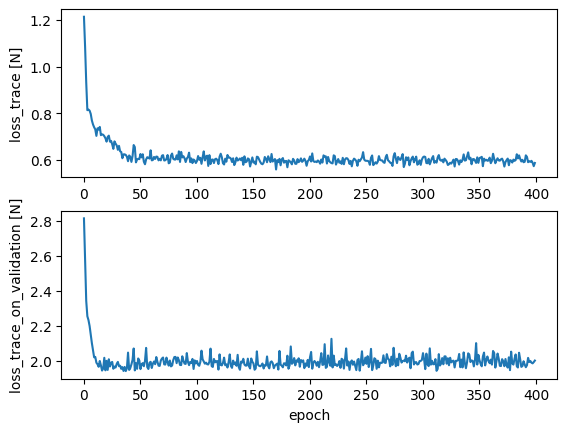

In [2]:
# use the data from previous section to train the model

factory = training_manager.PipelineFactory(training_manager.ModelArchitecture.SIMPLE_NET)
manager = factory.make_training_pipeline()
manager.set_up(
    training_data_menu=data_list,
    # training_data_menu=data_list[:4],    # use small data list for quick testing
    validation_data_menu=validation_list[:],
    input_label_map_file=path1,
    can_inspect_data=False
)
manager.train()

plt.show()  

Inspect data in the data list.

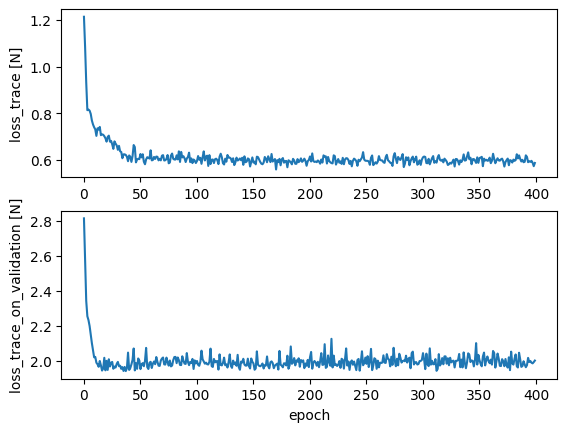

In [3]:
# trainer_instance.inspect_data(data_list[:2])
manager.show_result_only()

After training, we can save the model in the following way.

In [4]:
model_name = training_subfolder
manager.save_model(model_name)

Model saved to model\wind_near_wall_bemt_fitting.pth


Test the model using the test set.

test Data List:
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_x0_0_y0_0_z10_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_x0_0_y0_0_z1_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_x0_0_y0_0_z4_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_x0_0_y0_0_zn10_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_x0_0_y0_0_zn1_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_x0_0_y0_0_zn4_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_xn2_0_y0_0_z10_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_xn2_0_y0_0_z1_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_xn2_0_y0_0_z4_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_validation\test_wind_near_wall_xn2_0_y0_0_zn10_0_d0_5_validation.csv
wind_near_wall_bemt_fitting_vali

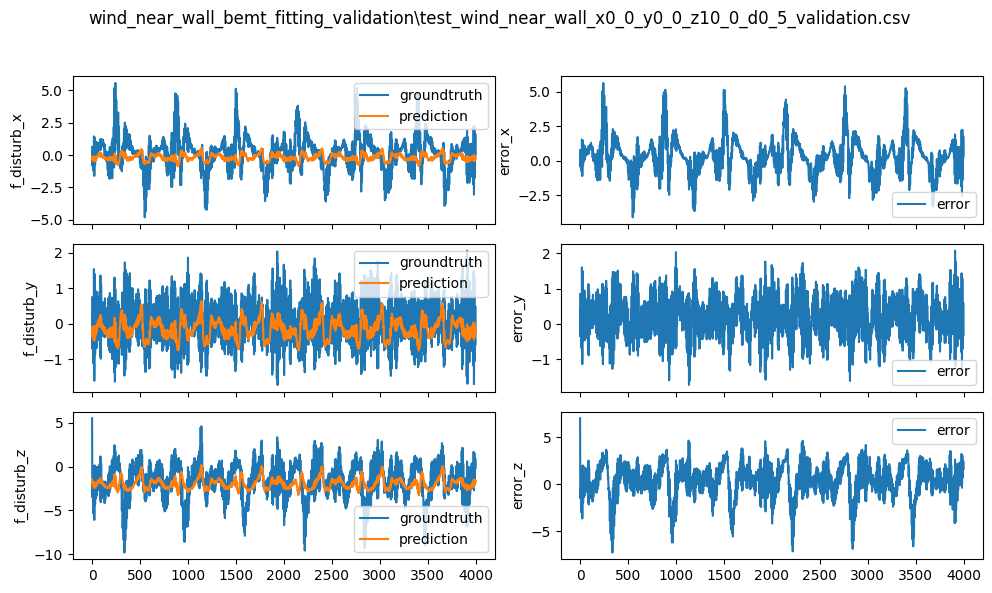

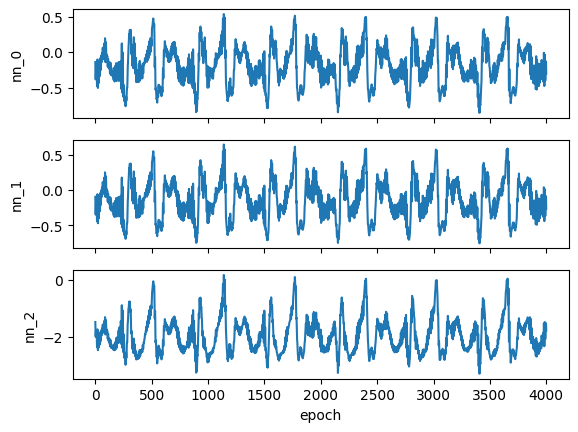

prediction: tensor([[ 0.0916,  0.1467, -0.5078],
        [-0.0287,  0.0225, -0.7295],
        [-0.1395, -0.0918, -0.9368],
        ...,
        [ 0.0428,  0.0973, -0.2686],
        [-0.0392,  0.0127, -0.4100],
        [-0.1904, -0.1433, -0.6709]])


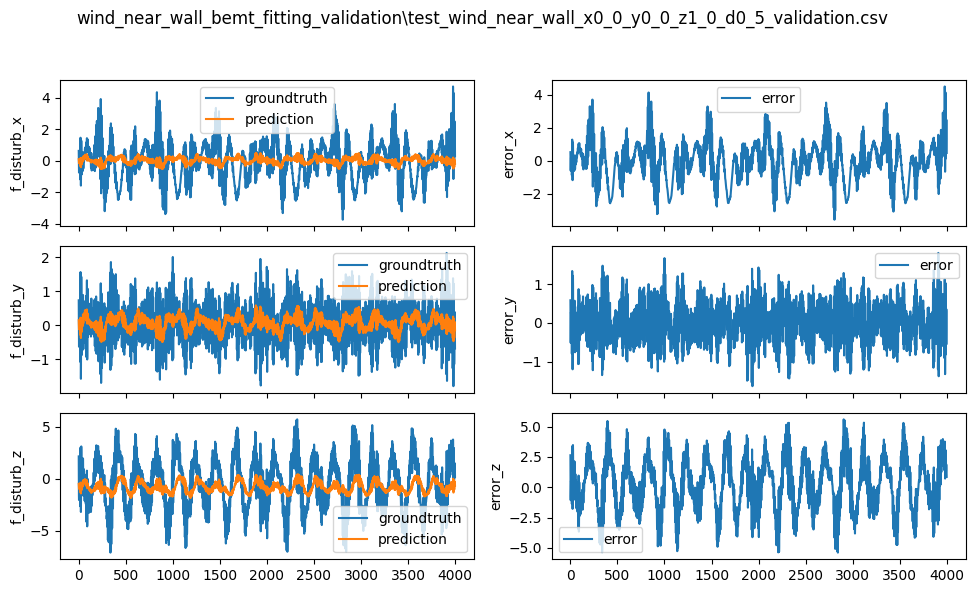

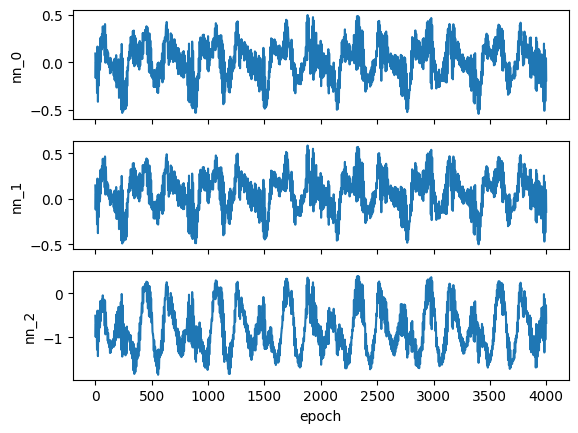

prediction: tensor([[ 0.0119,  0.0640, -0.8290],
        [-0.1024, -0.0540, -1.0456],
        [-0.1935, -0.1481, -1.2233],
        ...,
        [-0.0534, -0.0024, -0.5942],
        [-0.1387, -0.0904, -0.7498],
        [-0.2873, -0.2438, -1.0216]])


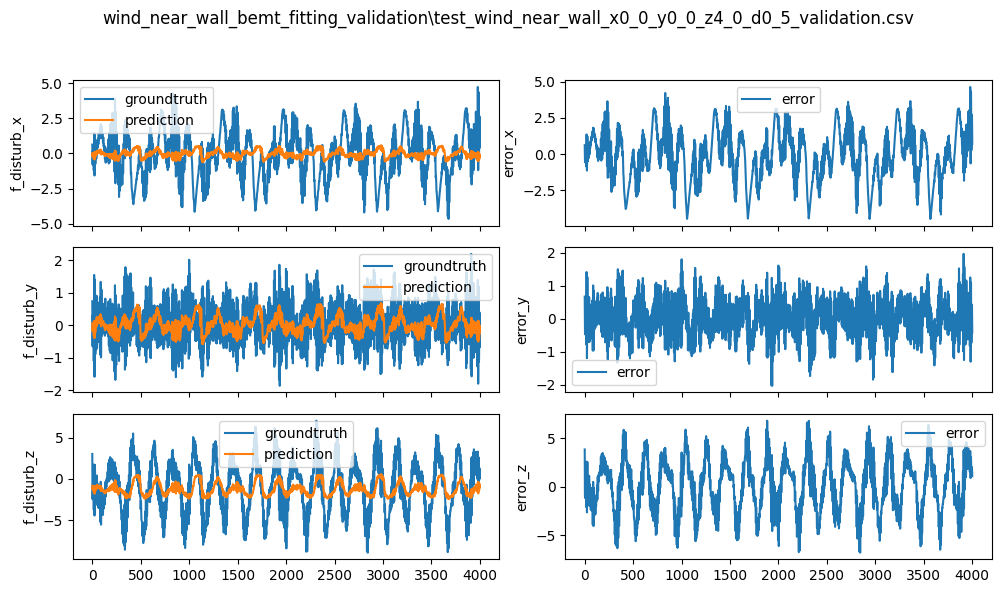

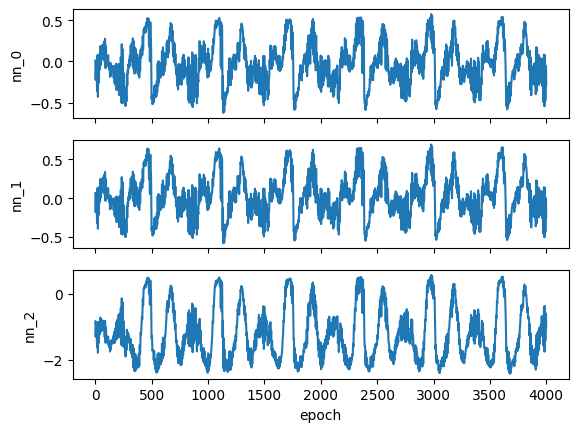

prediction: tensor([[ 5.5132e-04,  5.2180e-02, -8.1502e-01],
        [-1.2281e-01, -7.5154e-02, -1.0451e+00],
        [-2.1401e-01, -1.6930e-01, -1.2222e+00],
        ...,
        [-2.0470e-01, -1.5922e-01, -1.0311e+00],
        [-2.9157e-01, -2.4883e-01, -1.1713e+00],
        [-4.1566e-01, -3.7804e-01, -1.3796e+00]])


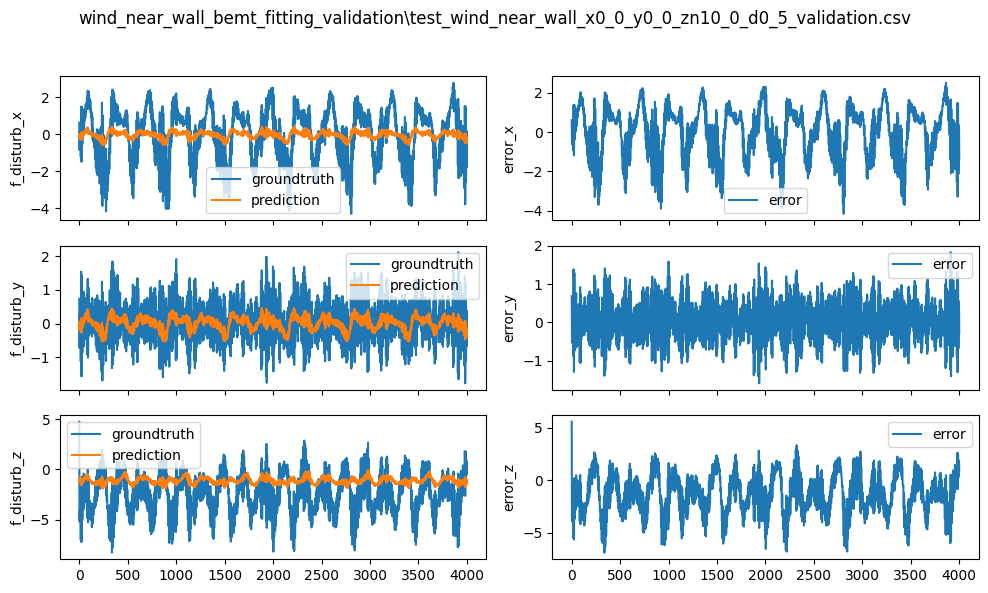

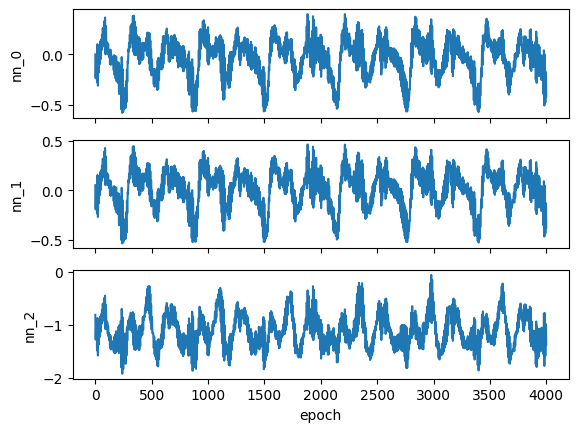

prediction: tensor([[ 0.0944,  0.1497, -0.4455],
        [-0.0244,  0.0272, -0.6476],
        [-0.1220, -0.0736, -0.8156],
        ...,
        [-0.0250,  0.0272, -0.3975],
        [-0.1035, -0.0538, -0.5328],
        [-0.2460, -0.2008, -0.7787]])


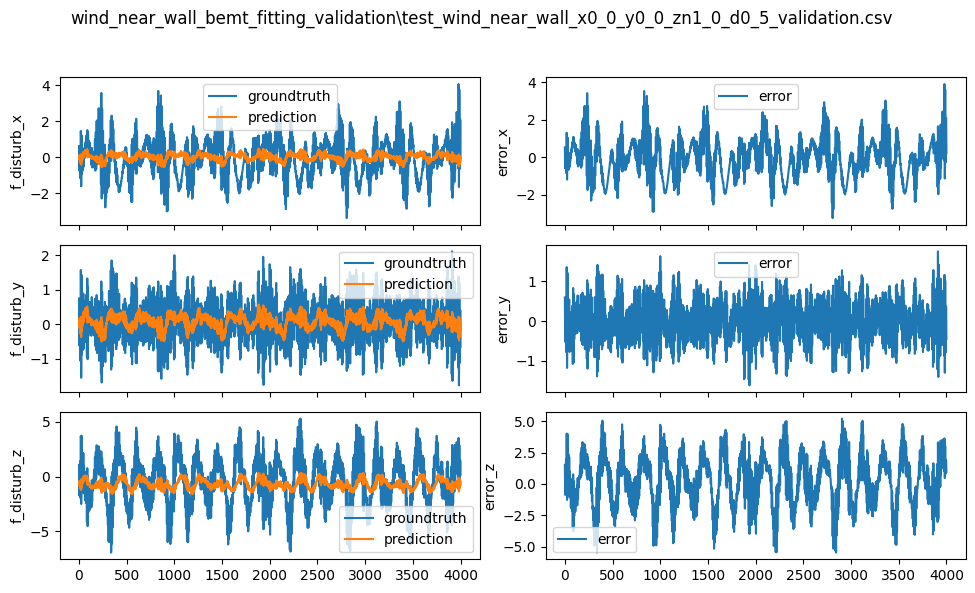

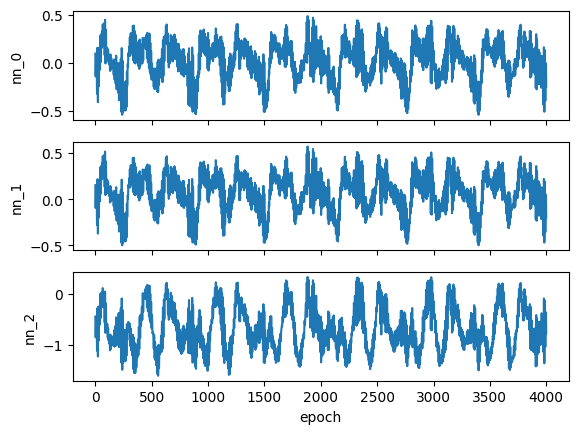

prediction: tensor([[ 0.0659,  0.1201, -0.5636],
        [-0.0448,  0.0058, -0.7543],
        [-0.1559, -0.1087, -0.9472],
        ...,
        [-0.1132, -0.0639, -0.5701],
        [-0.2104, -0.1642, -0.7374],
        [-0.3391, -0.2969, -0.9608]])


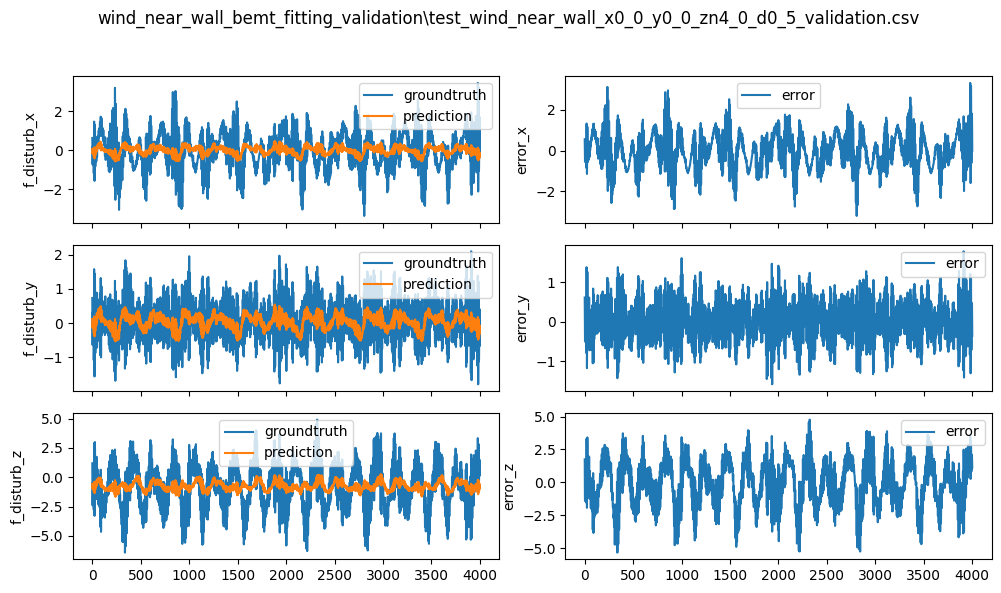

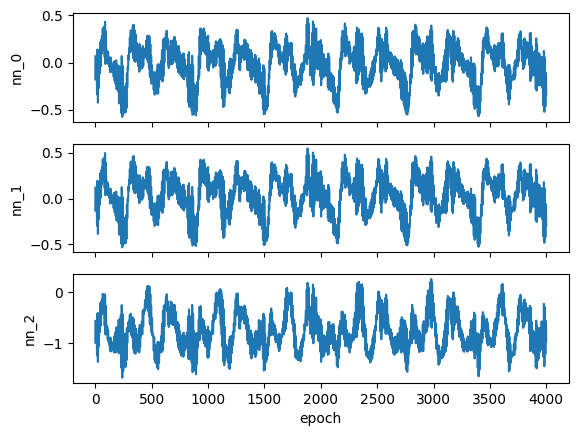

prediction: tensor([[-0.1226, -0.0761, -1.4615],
        [-0.2341, -0.1911, -1.6857],
        [-0.3472, -0.3079, -1.9155],
        ...,
        [-0.1691, -0.1244, -1.6866],
        [-0.2360, -0.1934, -1.7932],
        [-0.3277, -0.2880, -1.9442]])


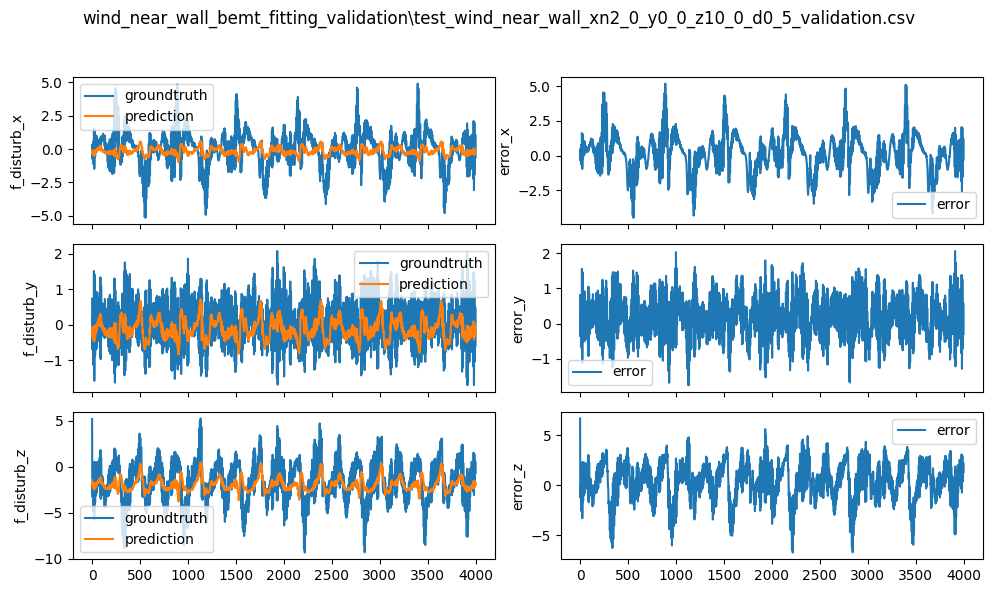

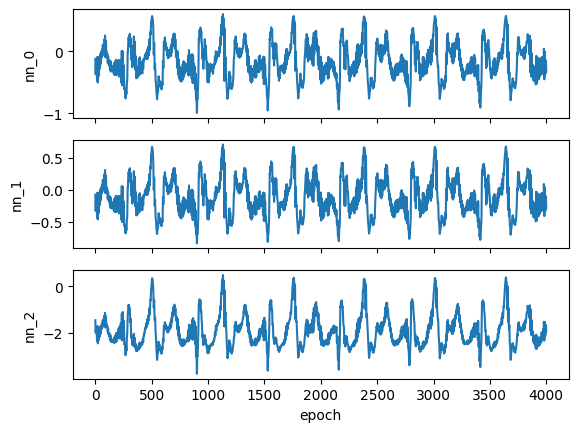

prediction: tensor([[ 1.2679e-01,  1.8293e-01, -4.7876e-01],
        [-5.2513e-03,  4.6644e-02, -7.2210e-01],
        [-1.1659e-01, -6.8281e-02, -9.3102e-01],
        ...,
        [-5.4772e-04,  5.2519e-02, -3.4939e-01],
        [-8.8083e-02, -3.7798e-02, -5.0024e-01],
        [-2.3957e-01, -1.9410e-01, -7.6163e-01]])


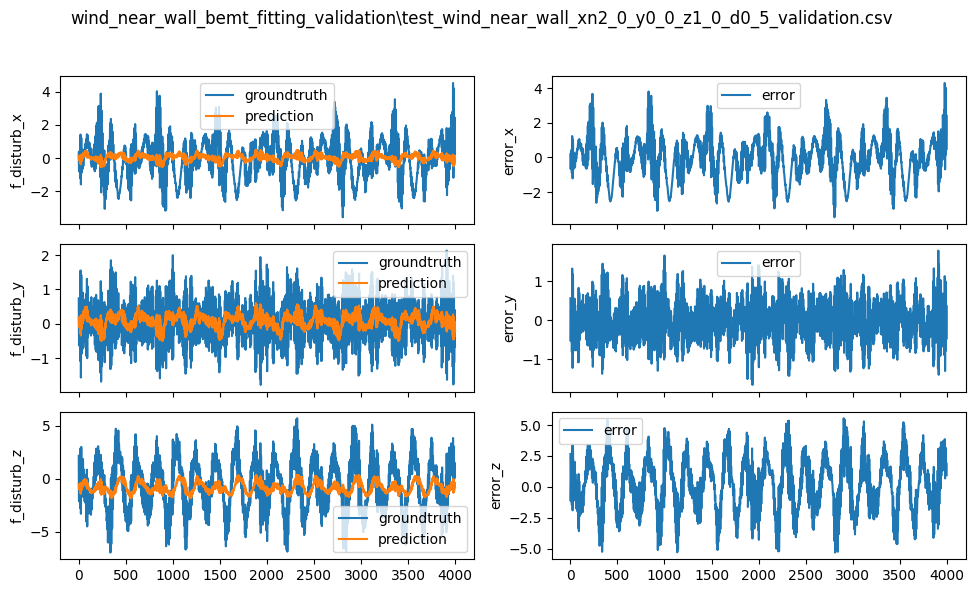

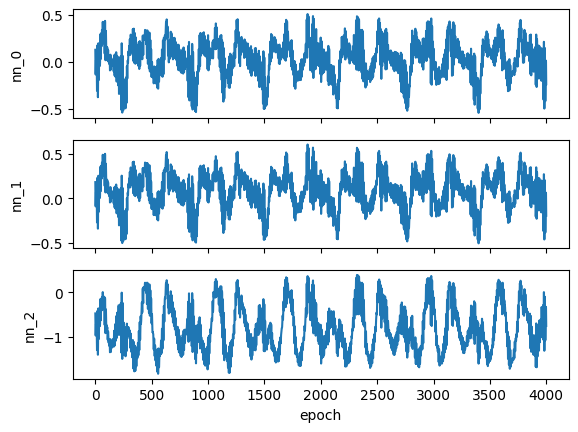

prediction: tensor([[ 0.0435,  0.0964, -0.8070],
        [-0.0771, -0.0281, -1.0400],
        [-0.1786, -0.1328, -1.2416],
        ...,
        [-0.1651, -0.1177, -0.7986],
        [-0.2547, -0.2102, -0.9615],
        [-0.4254, -0.3869, -1.2793]])


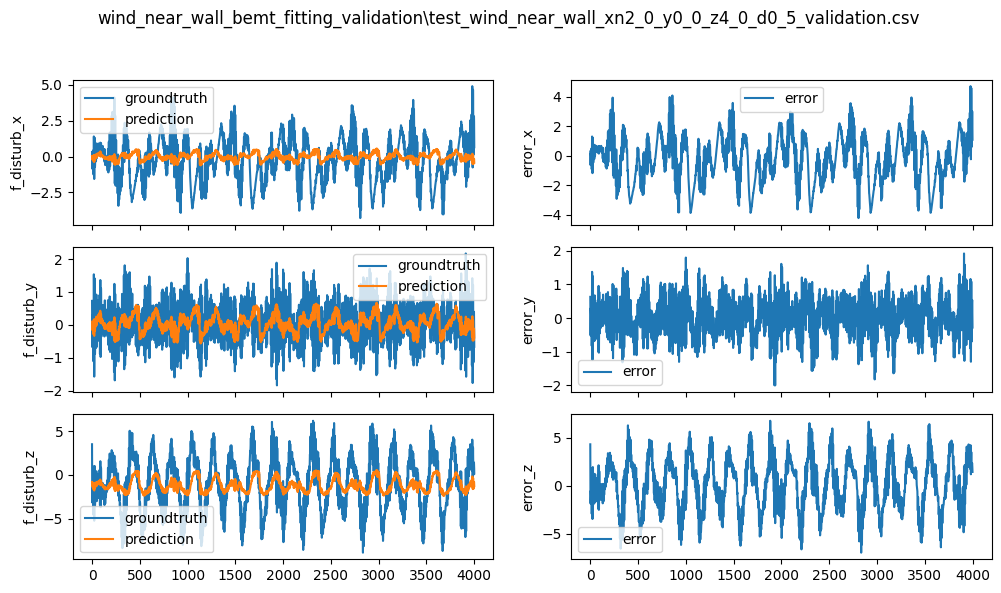

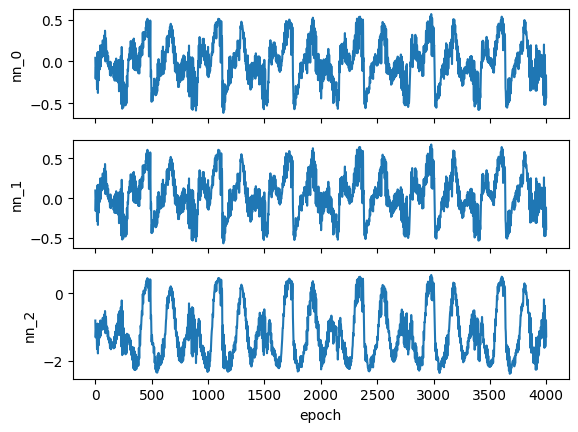

prediction: tensor([[ 0.0352,  0.0878, -0.7911],
        [-0.1007, -0.0524, -1.0417],
        [-0.2040, -0.1591, -1.2387],
        ...,
        [-0.1629, -0.1161, -0.9810],
        [-0.2558, -0.2120, -1.1318],
        [-0.3840, -0.3443, -1.3439]])


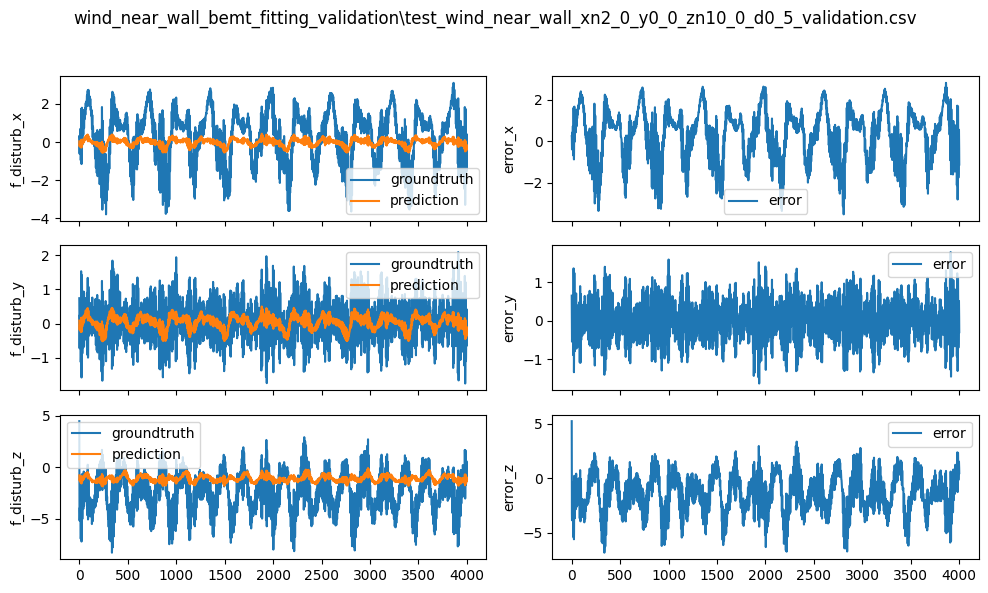

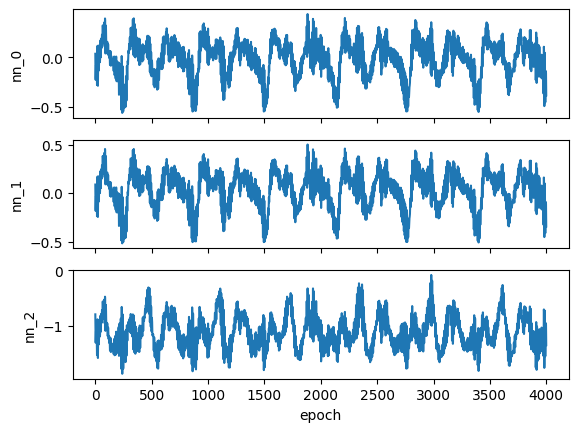

prediction: tensor([[ 0.1224,  0.1785, -0.4330],
        [ 0.0058,  0.0582, -0.6316],
        [-0.1059, -0.0570, -0.8238],
        ...,
        [-0.0020,  0.0510, -0.3590],
        [-0.0889, -0.0387, -0.5088],
        [-0.2523, -0.2073, -0.7908]])


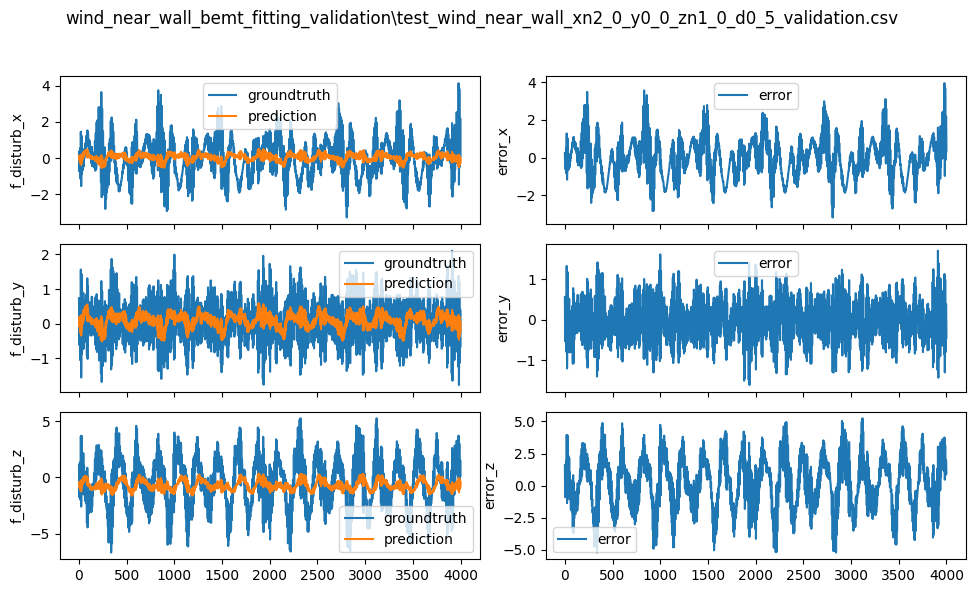

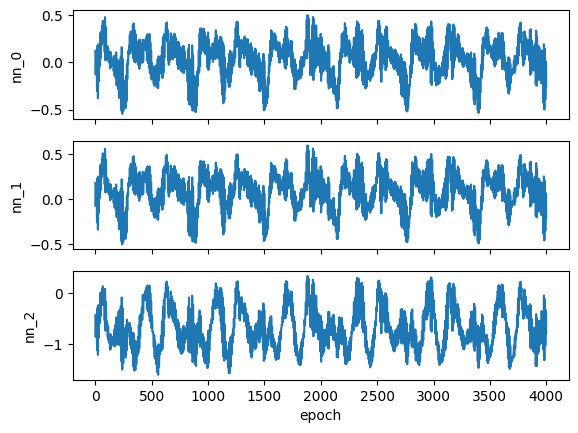

prediction: tensor([[ 0.0882,  0.1430, -0.5608],
        [-0.0364,  0.0144, -0.7749],
        [-0.1371, -0.0895, -0.9502],
        ...,
        [-0.0933, -0.0433, -0.5371],
        [-0.1912, -0.1444, -0.7051],
        [-0.3276, -0.2850, -0.9417]])


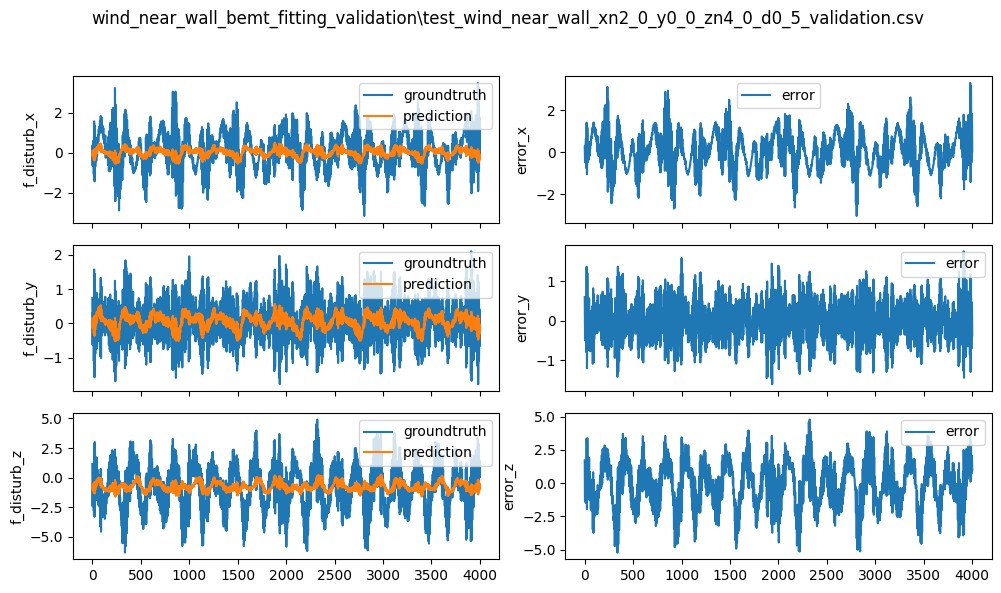

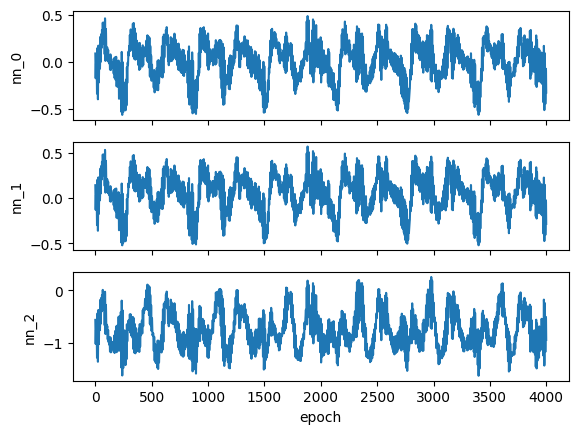

prediction: tensor([[-0.0742, -0.0262, -1.4256],
        [-0.1994, -0.1554, -1.6721],
        [-0.3124, -0.2721, -1.8995],
        ...,
        [-0.1367, -0.0908, -1.5398],
        [-0.2313, -0.1883, -1.6941],
        [-0.3506, -0.3114, -1.8943]])


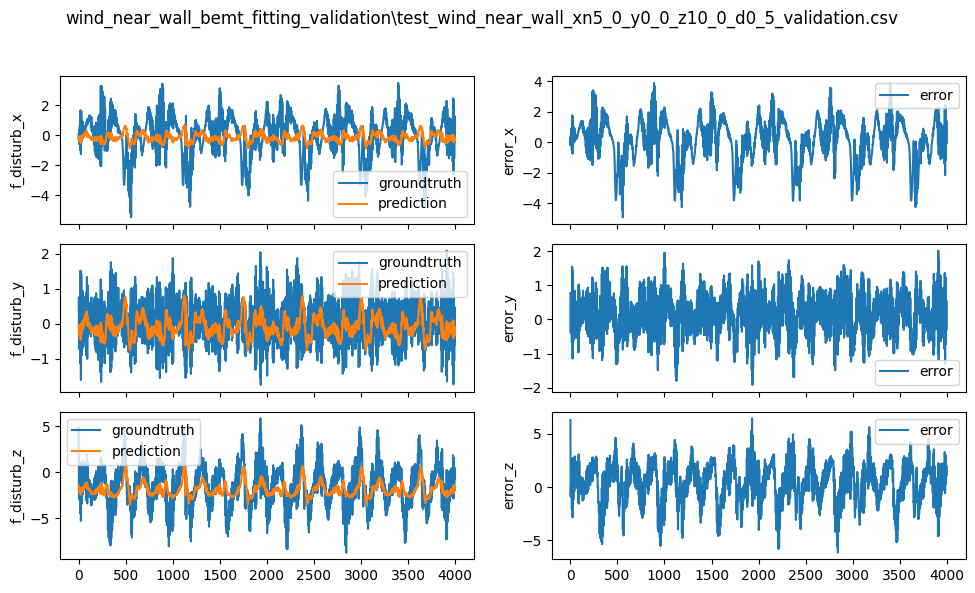

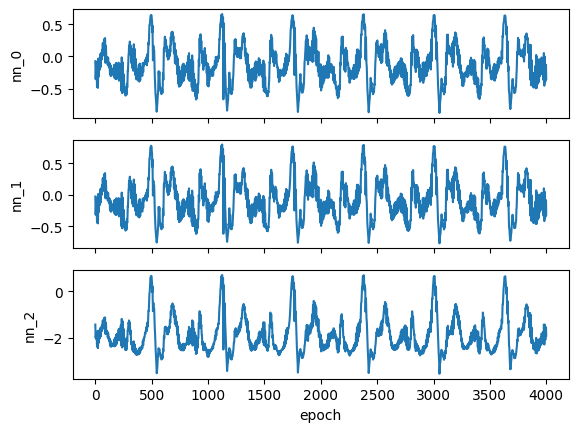

prediction: tensor([[ 0.1600,  0.2171, -0.4718],
        [ 0.0308,  0.0837, -0.7109],
        [-0.0848, -0.0356, -0.9297],
        ...,
        [-0.0184,  0.0341, -0.3898],
        [-0.1003, -0.0505, -0.5309],
        [-0.2398, -0.1944, -0.7730]])


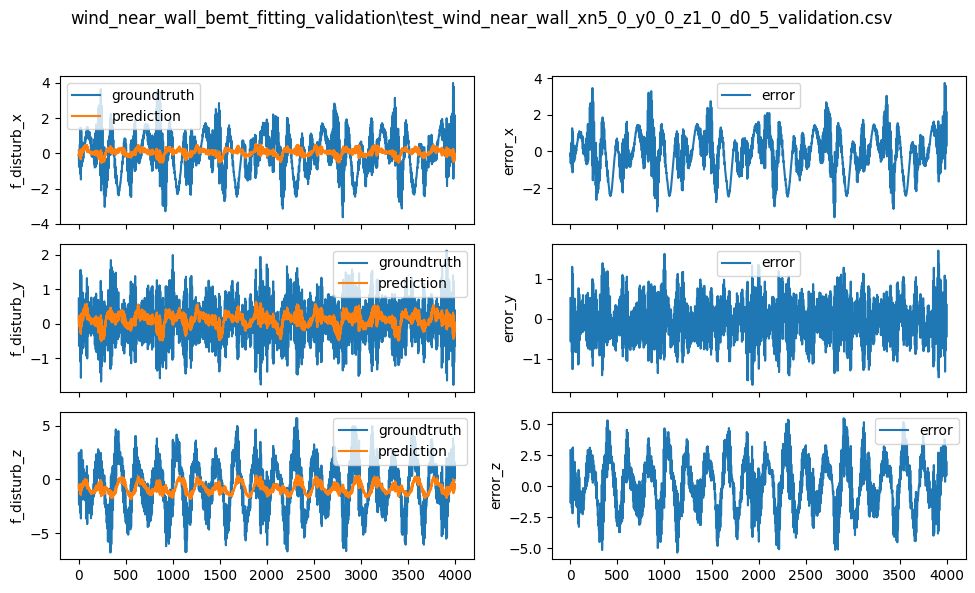

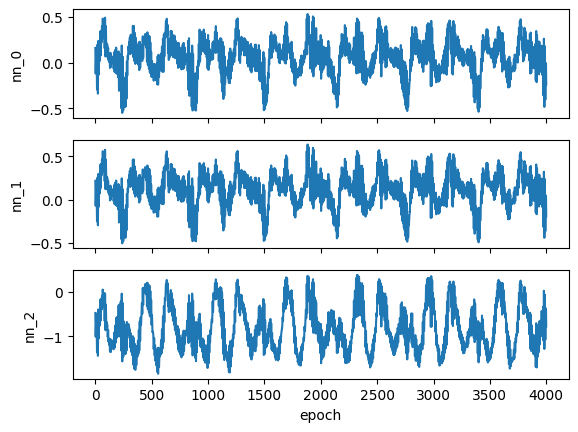

prediction: tensor([[ 0.0872,  0.1414, -0.7796],
        [-0.0413,  0.0088, -1.0253],
        [-0.1537, -0.1073, -1.2448],
        ...,
        [-0.1521, -0.1044, -0.8218],
        [-0.2403, -0.1955, -0.9854],
        [-0.4033, -0.3650, -1.2893]])


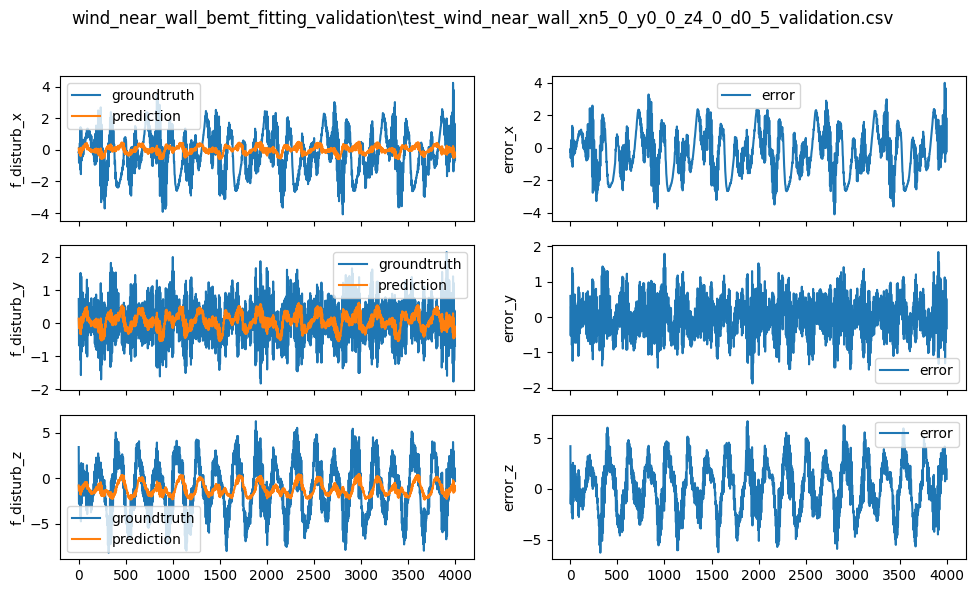

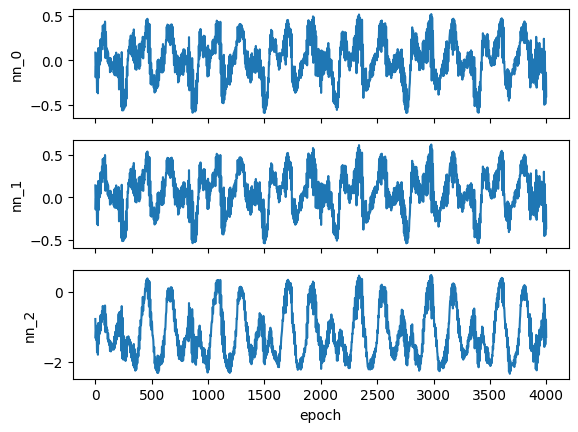

prediction: tensor([[ 0.0629,  0.1162, -0.7966],
        [-0.0651, -0.0158, -1.0338],
        [-0.1762, -0.1306, -1.2440],
        ...,
        [-0.0953, -0.0465, -0.8898],
        [-0.1746, -0.1282, -1.0163],
        [-0.3228, -0.2811, -1.2617]])


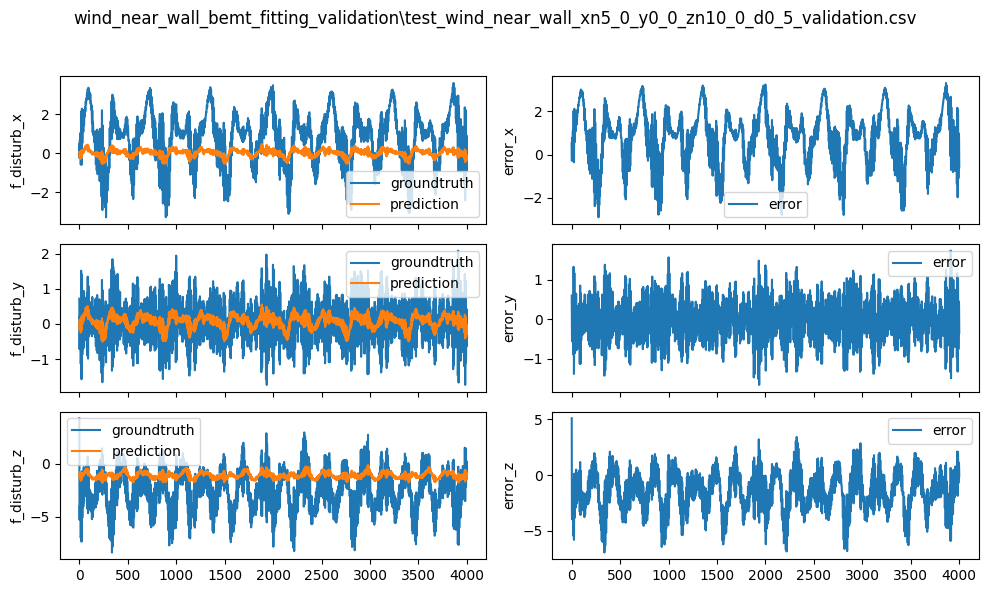

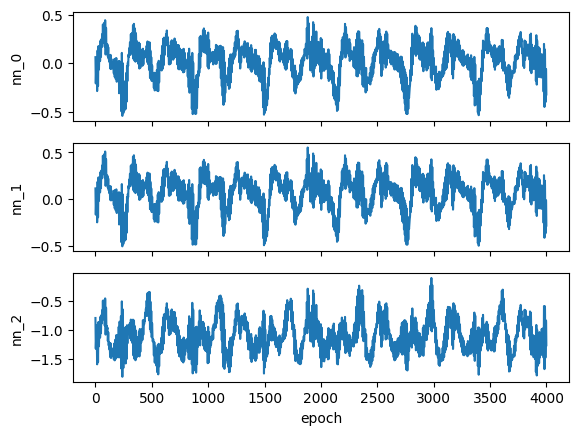

prediction: tensor([[ 0.1623,  0.2196, -0.4178],
        [ 0.0449,  0.0984, -0.6196],
        [-0.0772, -0.0275, -0.8311],
        ...,
        [-0.0386,  0.0132, -0.4305],
        [-0.1262, -0.0772, -0.5825],
        [-0.2753, -0.2311, -0.8416]])


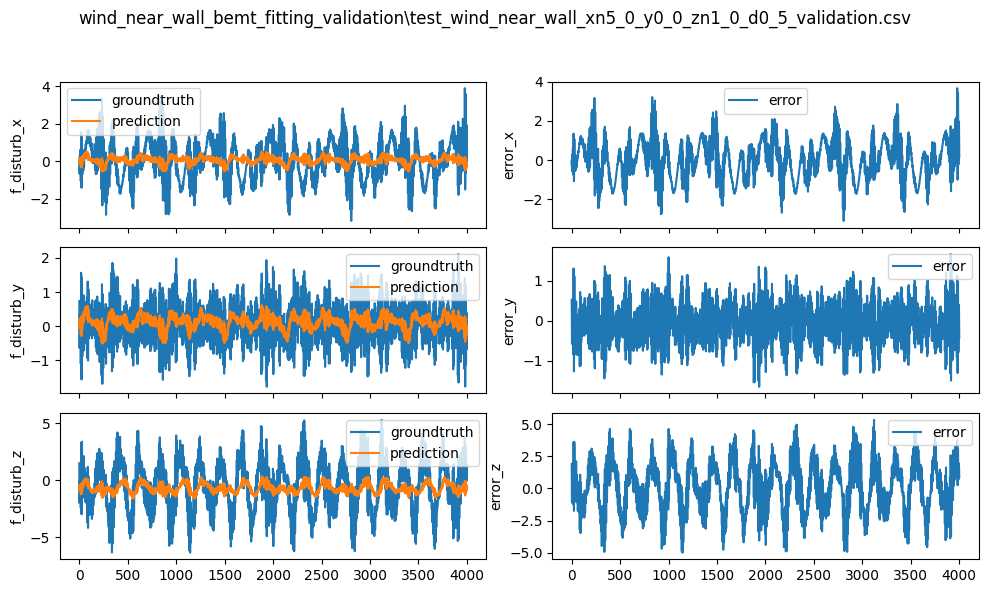

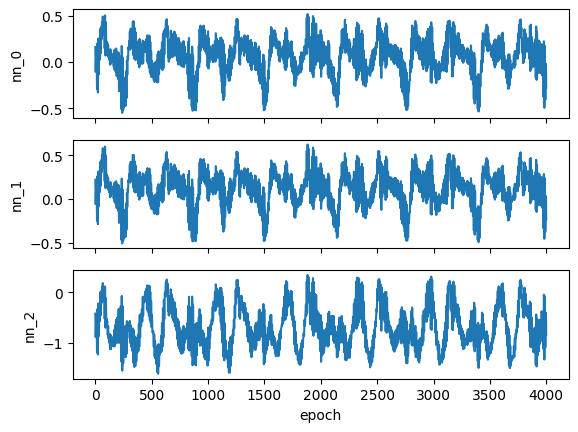

prediction: tensor([[ 0.1287,  0.1847, -0.5445],
        [ 0.0029,  0.0549, -0.7609],
        [-0.1202, -0.0722, -0.9745],
        ...,
        [-0.0718, -0.0211, -0.5049],
        [-0.1646, -0.1169, -0.6642],
        [-0.3085, -0.2654, -0.9123]])


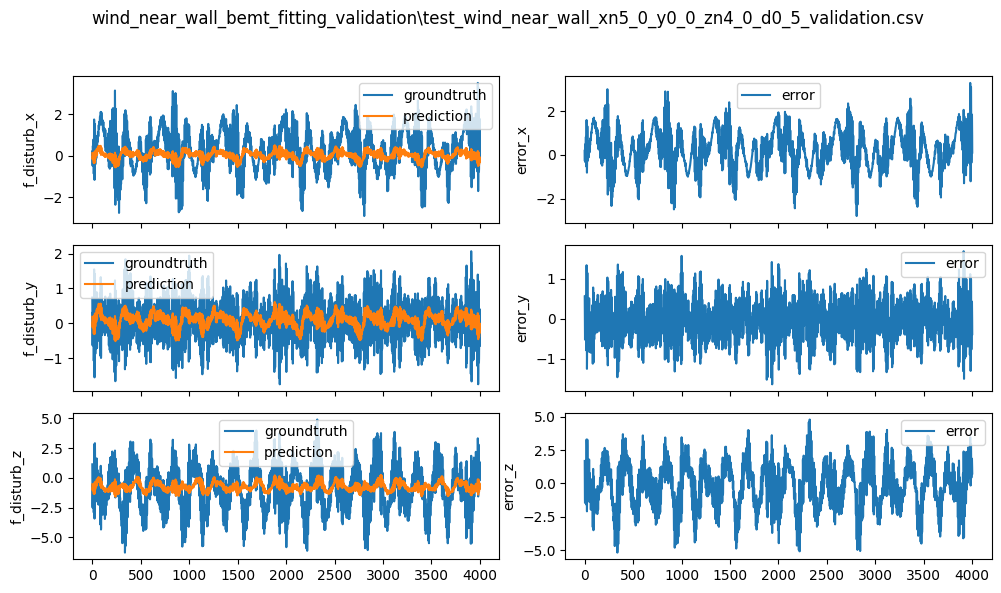

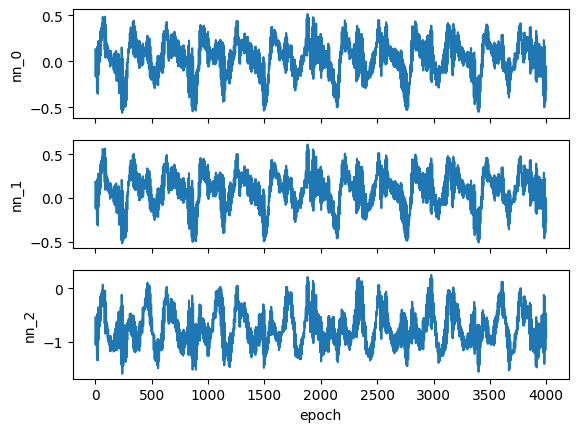

average rms for dim 0: 1.190402993915215
average rms for dim 1: 0.4955090434520688
average rms for dim 2: 2.047818210256277


c:\YimingVirtualDDrive\7_workSpace\repo\neural-fly\Simulation\learning\validator.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


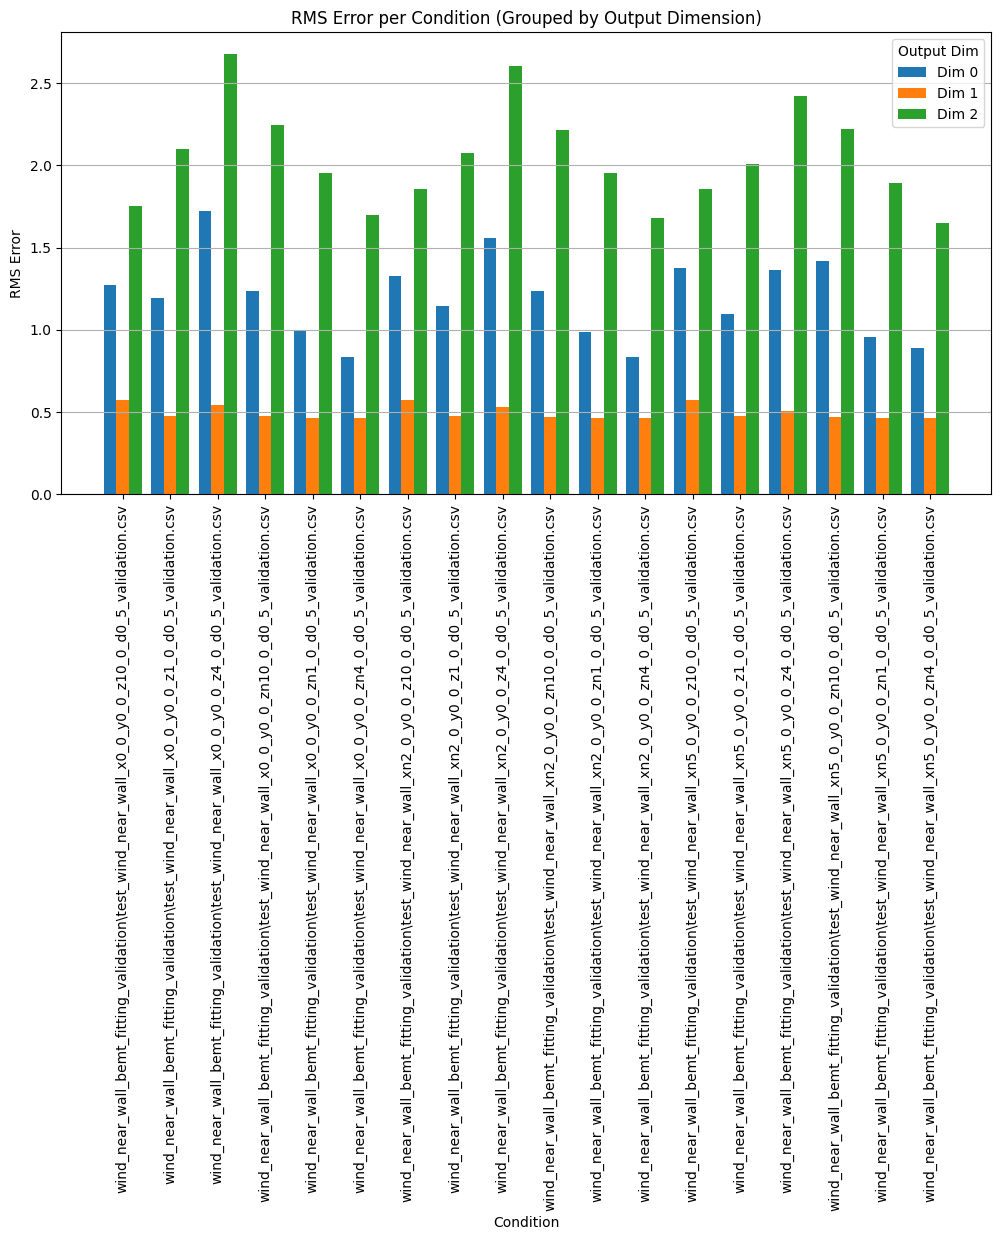

overall average mse after train: 6.003281669215861 before train: 8.653629129265086
average mse for dim 0: after train: 1.4755865832415445 before train: 1.553607158270077
average mse for dim 1: after train: 0.2472338049437248 before train: 0.31985893137513793
average mse for dim 2: after train: 4.2804612810305915 before train: 6.780163039619872


c:\YimingVirtualDDrive\7_workSpace\repo\neural-fly\Simulation\learning\validator.py:120: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


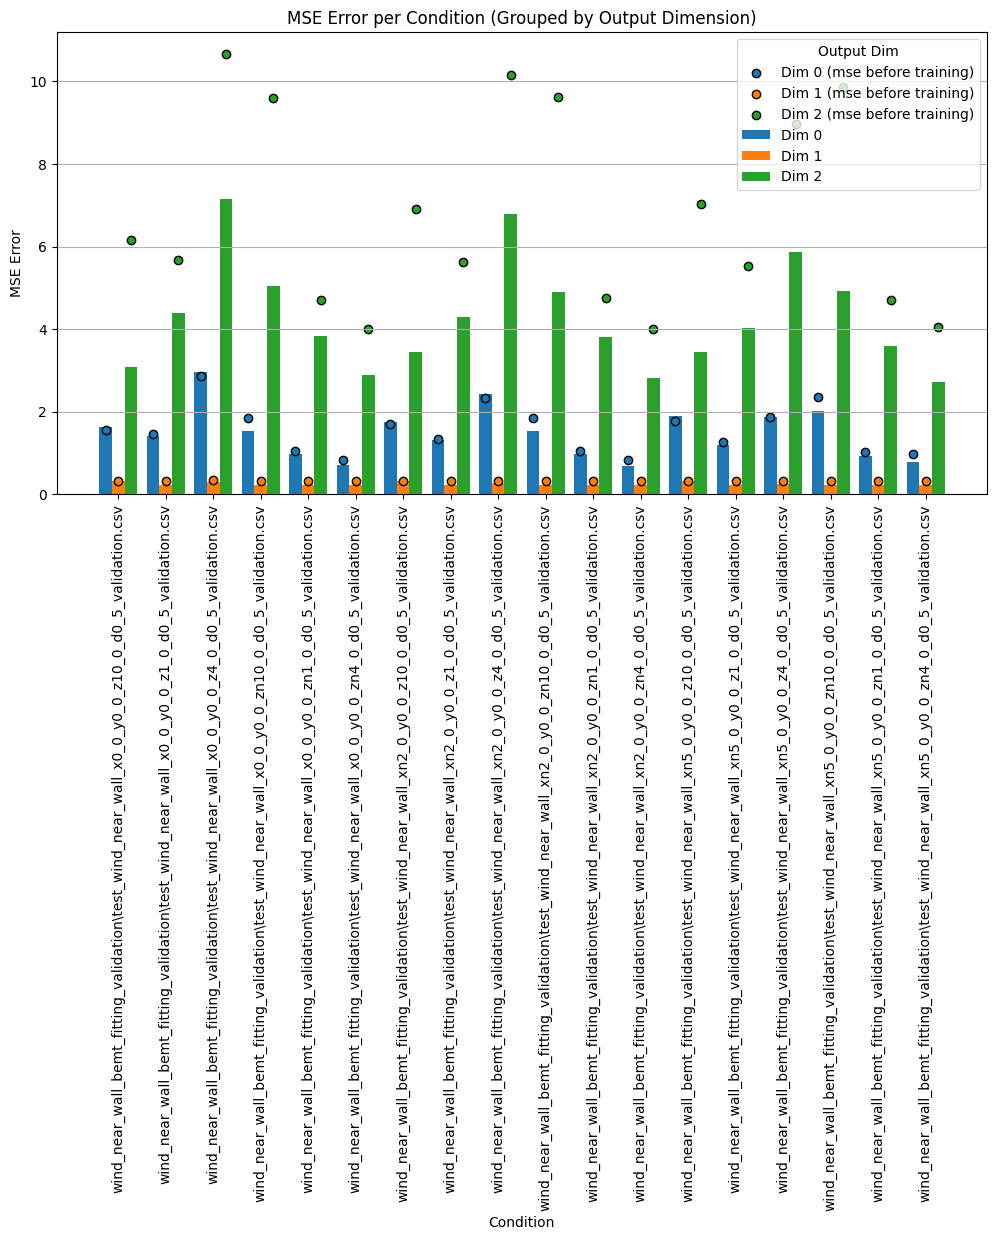

In [5]:
%matplotlib inline
# %matplotlib tk
model_name = training_subfolder

subfolder = validation_subfolder
# subfolder = "wind_near_wall_bemt_fitting_validation"
# subfolder = "nf_validation_back2back"
data_list = generate_data_list(subfolder)
print("test Data List:")
for data in data_list:
    print(data)

# debug
# data_list = data_list[:1]  # use small data list for quick testing
# factory = training_manager.PipelineFactory(training_manager.ModelArchitecture.SIMPLE_NET)
manager = factory.make_test_pipeline()

manager.set_up(
    data_menu=data_list,
    input_label_map_file=path1,
    model_name=model_name
)

# make a new trainer to replicate the above setup, just to allow verify_model to work
manager.test()
plt.show()  
